<a href="https://colab.research.google.com/github/TRACE-Structures/digital_twinning/blob/main/demo/notebooks/hybrid_pilot_example_fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Tall Timber Building with Bayesian Digital Twinning**  

This framework demonstrates **Bayesian Digital Twinning** for a seven-storey **cross-laminated timber (CLT) building** in Glasgow, UK. The model dynamically updates structural parameters using experimental modal data to refine predictions and quantify uncertainties.  

### **System Overview**  
The building’s dynamic behavior is governed by eigenfrequencies and mode shapes derived from a finite element (FE) model. Key parameters include:  
- **Stiffness properties**: Elastic moduli (\(e_1, e_2, e_3\)) and shear moduli (\(g_1, g_2\)) of CLT panels.  
- **Mass distribution**: Additional distributed mass (\(q\)) across floors.  
- **Uncertainty sources**: Material variability, joint stiffness, and measurement noise.  

### **Probabilistic Framework**  
A **Bayesian inversion** updates parameters using experimental modal data (frequencies and mode shapes). The workflow includes:  
1. **Surrogate Modeling**: A generalized Polynomial Chaos (gPC) expansion replaces costly FE simulations, approximating eigenfrequencies/mode shapes as functions of parameters.  
2. **Mode Tracking**: k-means clustering partitions mode shapes to address mode-switching issues, ensuring consistent pairing between numerical and experimental modes.  
3. **Uncertainty Quantification**: Sobol indices identify influential parameters, while posterior distributions reflect updated confidence in stiffness and mass values.  

### **Key Innovations**  
- **Hybrid Data Integration**: Combines forced vibration test data (FRFs) with FE-derived modal properties.  
- **Error Modeling**: Accounts for measurement noise (e.g., eigenfrequency standard deviations: 0.02–0.19 Hz) and modeling approximations.  
- **Adaptive Clustering**: Low-rank representations and extended mode shape vectors improve clustering accuracy despite spatial aliasing.  

### **Visualizations & Results**  
- **Eigenfrequency Distributions**: Prior vs. posterior uncertainties (e.g., Mode 1: 2.77±0.18 Hz → 2.84±0.01 Hz).  
- **MAC Matrix**: Modal Assurance Criterion highlights correlations between experimental and numerical mode shapes.  
- **Parameter Sensitivity**: Sobol indices show \(g_1\) (wall shear stiffness) dominates Mode 1–3, while \(g_2\) (floor shear) affects Mode 5.  
- **3D Scatter Plots**: Posterior parameter distributions and correlations (e.g., \(e_1\) vs. \(g_1\) trade-offs).  

<div style="text-align: center;">
    <img src="https://raw.githubusercontent.com/TRACE-Structures/digital_twinning/main/demo/data/Yoker_building/yoker_building.png" alt="Yoker Building" width="580">
</div>  

### **Conclusion**  
The Bayesian digital twin provides a **probabilistic FE model** that aligns with experimental data while quantifying uncertainties. It reveals as-built stiffness reductions in joints and validates timber as a viable material for tall structures. This approach bridges gaps in traditional deterministic methods, offering actionable insights for vibration serviceability assessments.

# Imports

In [1]:
! pip install digital_twinning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.8/80.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.5/69.5 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 74.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 27.0 MB/s eta 0:00:00


In [2]:
from IPython.display import display
import ipywidgets as widgets
widgets.Widget.close_all()

In [3]:
from uncertain_variables import *
import digital_twinning as dt
import pandas as pd

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Generate data

## Define Variables and VariableSet

In [4]:
param_names = ["e1", "e2", "e3", "g1", "g2", 'q']

P1 = Variable("e1", UniformDistribution(6, 12))
P2 = Variable("e2", UniformDistribution(10, 13))
P3 = Variable("e3", UniformDistribution(6, 12))
P4 = Variable("g1", UniformDistribution(400, 750))
P5 = Variable("g2", UniformDistribution(200, 500))
P6 = Variable('q', UniformDistribution(5, 100))

# Create a set to store simulation parameters.
Q = VariableSet()

# Add the defined parameters (mass and stiffness) to the parameter set.
Q.add(P1)
Q.add(P2)
Q.add(P3)
Q.add(P4)
Q.add(P5)
Q.add(P6)

## Sampling
Sampling is already made. We just read the sample points from a file.

In [5]:
data_path = 'https://raw.githubusercontent.com/TRACE-Structures/digital_twinning/main/demo/data/Yoker_building/'
Q_df = pd.read_csv(data_path + 'x_df.csv')

Output data from FEM solver

In [6]:
QoI_df = pd.read_csv(data_path + 'y_df.csv')
QoI_names = QoI_df.columns.to_list()

# Model

## **Choosing the Model**

In this notebook, we implement the model using one of the following methods: **gPCE**, **DNN**, or **GBT**.

- **gPCE (Generalized Polynomial Chaos Expansion)**: Models uncertainty by expressing the output as a polynomial expansion, with coefficients determined by projecting the system's response onto orthogonal polynomials.

- **DNN (Deep Neural Networks)**: Machine learning models composed of interconnected neurons, capable of learning complex, non-linear patterns from data.

- **GBT (Gradient Boosting Trees)**: Combines weak decision trees into a strong predictive model, iteratively correcting errors from previous trees for robust performance.


In [7]:
method = "gPCE"

Set configurations

In [8]:
# Model configurations
match method:
    # DNN model configurations
    case "DNN":
        config = {
            'init_config' : {
                'layers': [
                    {'neurons': 512, 'activation': 'relu', 'dropout': 0.2},
                    {'neurons': 256, 'activation': 'sigmoid', 'dropout': 0.2},
                    {'neurons': 256, 'activation': 'sigmoid', 'dropout': 0.2},
                    {'neurons': 128, 'activation': 'relu', 'dropout': None},
                    ],
                'outputAF': 'tanh'
                },
            'train_config' : {
                'optimizer': 'Adam',
                'loss': 'MSE',
                'epochs': 100,
                'batch_size': 32,
                'k_fold': None,
                'early_stopping': {
                    'patience': 25,
                    'min_delta': 0.0001}
                }
                }
    # gPCE model configurations
    case "gPCE":
        config = {
            'init_config' : {
            'p' : 4
            },
            'train_config' : {
                'k_fold': 9
                }
        }
    # GBT model configurations
    case "GBT":
        config = {
            'init_config' : {
                'gbt_method': 'xgboost'
            },
            'train_config' : {
                'max_depth': 6,
                'num_of_iter': 250,
                'k_fold': 9
                }
        }

In [9]:
split_config = {
        'train_test_ratio': 0.8,
        'random_seed': 1997,
        'split_type': 'no_shuffle'
        }

## Define model

In [10]:
# Initialize surrogate model
# This creates an instance of the SurrogateModel class using the provided sampling data (Q),
model = dt.SurrogateModel(Q, QoI_names, method, **config['init_config'])
# Split data into training and testing sets
X_train, X_test, y_train, y_test = model.train_test_split(Q_df, QoI_df, **split_config)
# Train the model
model.train(X_train, y_train, **config['train_config'])

----- Training started for 'gPCE' model -----
Fold 1/9
Fold 2/9
Fold 3/9
Fold 4/9
Fold 5/9
Fold 6/9
Fold 7/9
Fold 8/9
Fold 9/9
Average train loss: 0.00000005712744, Average valid loss: 0.00000006250216
----- Training ended for 'gPCE' model -----


In [11]:
# get mean and variance of surrogate model
mean, var = model.get_mean_and_var()
mean, var

(array([ 2.77428345,  2.85046978,  2.93671704,  3.77215049,  0.40811013,
         0.24680903,  0.30182584,  0.34775892,  0.21175028,  0.27594629,
         0.16882912,  0.201015  ,  0.12360387,  0.1245859 ,  0.07667948,
         0.05260213,  0.03244511, -0.31325189,  0.03031611, -0.17121614,
        -0.26708298,  0.02650839, -0.21124564,  0.02078296, -0.15164905,
         0.01666362, -0.09110047,  0.01147338, -0.03394582,  0.00550617,
         0.22434728,  0.23628339,  0.23308197,  0.19318081,  0.20084452,
         0.15469093,  0.15844989,  0.11385673,  0.11402805,  0.07146212,
         0.06904764,  0.03139773,  0.02802767,  0.31361243,  0.30767566,
         0.31172177,  0.27175561,  0.26888954,  0.21850398,  0.21624234,
         0.16045798,  0.16271229,  0.09894878,  0.10456167,  0.0394915 ,
         0.04664684,  0.21178828,  0.3243024 ,  0.28592573,  0.18174531,
         0.27517641,  0.14475065,  0.21641491,  0.10640713,  0.1564769 ,
         0.06699476,  0.0954865 ,  0.02944982,  0.0

In [12]:
model.model.mean()

array([ 2.77428345,  2.85046978,  2.93671704,  3.77215049,  0.40811013,
        0.24680903,  0.30182584,  0.34775892,  0.21175028,  0.27594629,
        0.16882912,  0.201015  ,  0.12360387,  0.1245859 ,  0.07667948,
        0.05260213,  0.03244511, -0.31325189,  0.03031611, -0.17121614,
       -0.26708298,  0.02650839, -0.21124564,  0.02078296, -0.15164905,
        0.01666362, -0.09110047,  0.01147338, -0.03394582,  0.00550617,
        0.22434728,  0.23628339,  0.23308197,  0.19318081,  0.20084452,
        0.15469093,  0.15844989,  0.11385673,  0.11402805,  0.07146212,
        0.06904764,  0.03139773,  0.02802767,  0.31361243,  0.30767566,
        0.31172177,  0.27175561,  0.26888954,  0.21850398,  0.21624234,
        0.16045798,  0.16271229,  0.09894878,  0.10456167,  0.0394915 ,
        0.04664684,  0.21178828,  0.3243024 ,  0.28592573,  0.18174531,
        0.27517641,  0.14475065,  0.21641491,  0.10640713,  0.1564769 ,
        0.06699476,  0.0954865 ,  0.02944982,  0.03929429, -0.14

## Calculate Sobol Sensitivities

In [13]:
# set max_index for Sobol sensitivity analysis
max_index = 2

partial_variance, sobol_index = model.get_sobol_sensitivity(max_index)

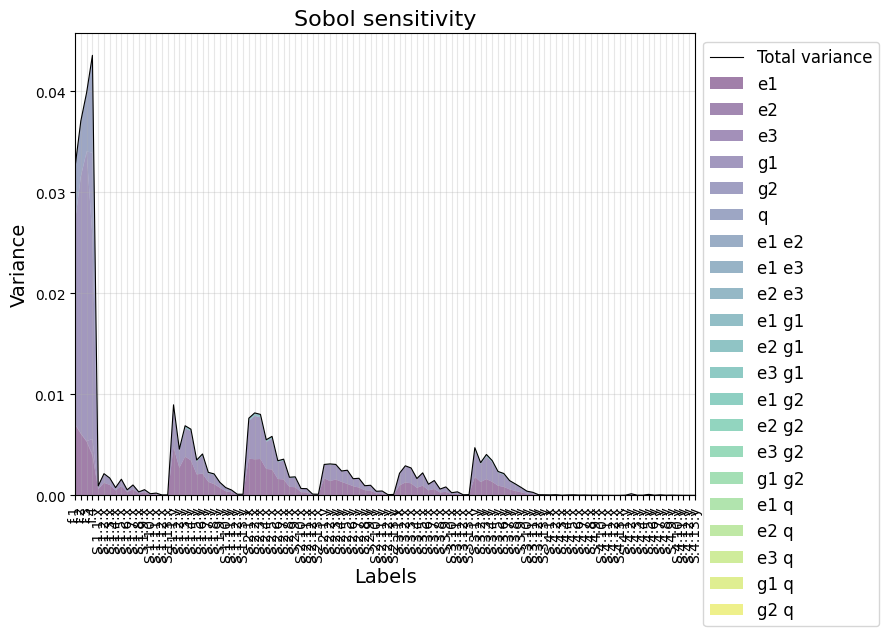

In [14]:
# Plot Sobol Sensitivity Index
# The 'plot_sobol_sensitivity' method generates a plot of Sobol Sensitivity indices, which quantify
# the contribution of each input parameter to the output uncertainty.
# - max_index: Specifies the maximum index of parameters to consider in the plot.
fig = model.plot_sobol_sensitivity(y_train, max_index=max_index)

## Calculate SHAP values

In [15]:
# 1 point from the data
q_sample_df = X_test.iloc[100:101]

In [16]:
# Calculate SHAP (Shapley Additive Explanations) values
# The 'get_shap_values' method computes the SHAP values for the model's test data (model.X_test).
# SHAP values explain the contribution of each input feature to the prediction for each test sample.
# - model.X_test.iloc[:100]: The first 100 samples from the test set are selected for SHAP value computation.
# SHAP values help to interpret the model's decisions and understand the impact of each input parameter on the output.
shap_values = await model.get_shap_values(X_test.iloc[:100])


Message: sample size for shap values is set to 100.


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

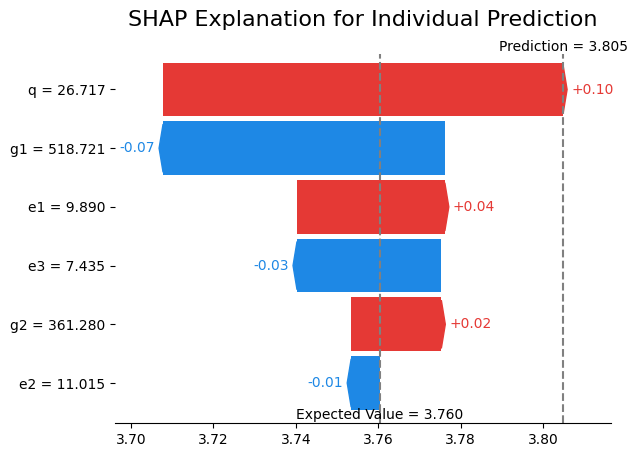

In [17]:
# Plot SHAP Single Waterfall Plot
# The 'plot_shap_single_waterfall' method generates a SHAP waterfall plot for a single test sample,
# visualizing how each feature contributes to the model's prediction for that sample.
# - q_sample_df: A DataFrame containing the sample data (e.g., a specific parameter set) for which the SHAP values are calculated.
# - param_name: The name of the quantity of interest (QoI) being analyzed ('f.4' in this case).
# The SHAP waterfall plot shows the cumulative effect of each feature on the model's prediction, helping to interpret individual predictions.
fig = await model.plot_shap_single_waterfall(X_test, q=q_sample_df, param_name='f.4')

  0%|          | 0/1 [00:00<?, ?it/s]

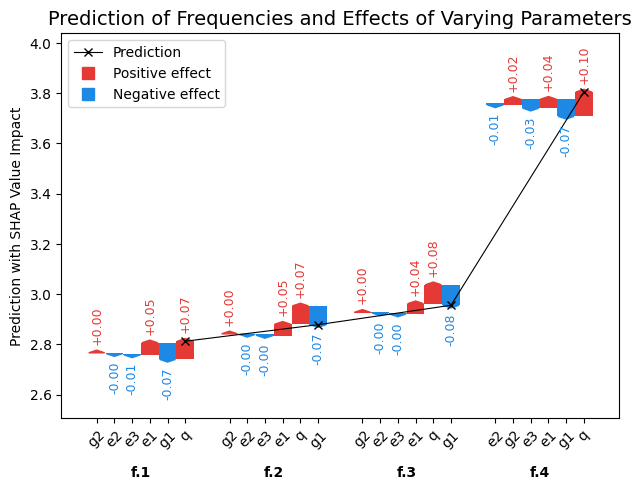

In [18]:
# Generate SHAP (Shapley values) waterfall plots for multiple features
# 'q_sample_df' contains the uncertain parameters sample, which will be passed as input to the SHAP model.
# The 'plot_shap_multiple_waterfalls' function will generate individual waterfall plots

fig = await model.plot_shap_multiple_waterfalls(X_test, q=q_sample_df, param_name='freq')

  0%|          | 0/1 [00:00<?, ?it/s]

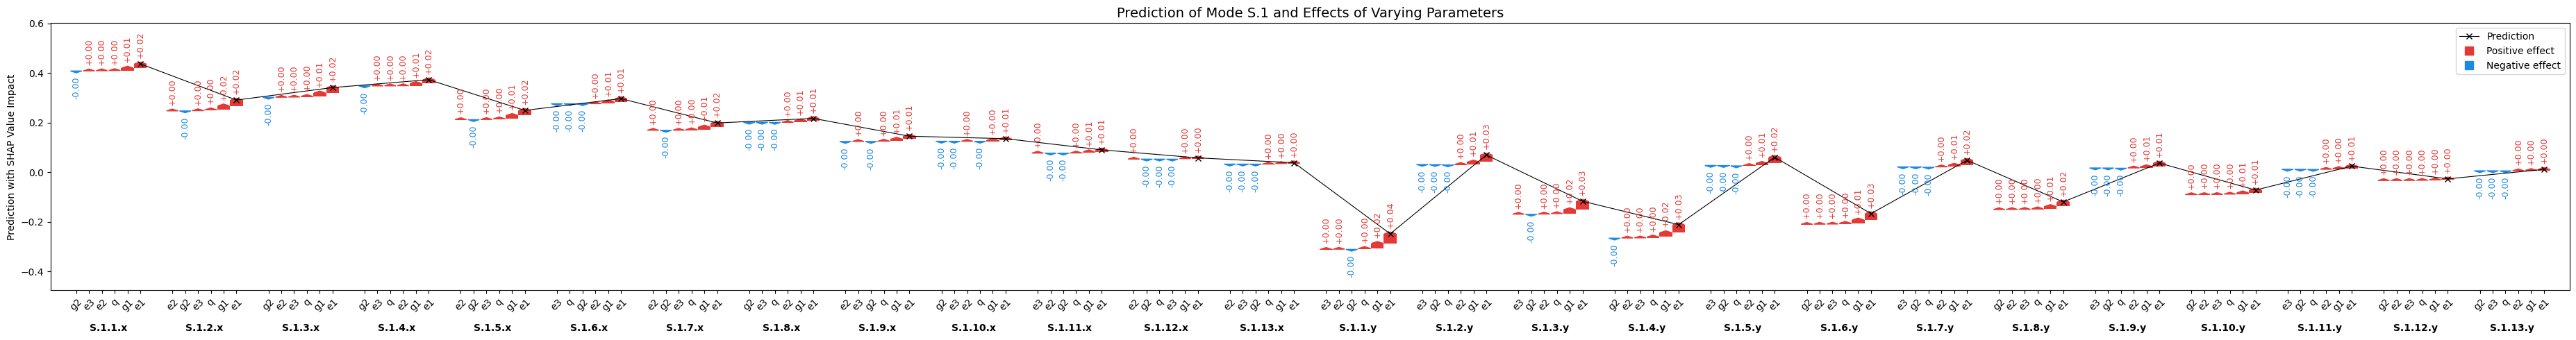

In [19]:
fig = await model.plot_shap_multiple_waterfalls(X_test, q=q_sample_df, param_name='S.1')

  0%|          | 0/100 [00:00<?, ?it/s]

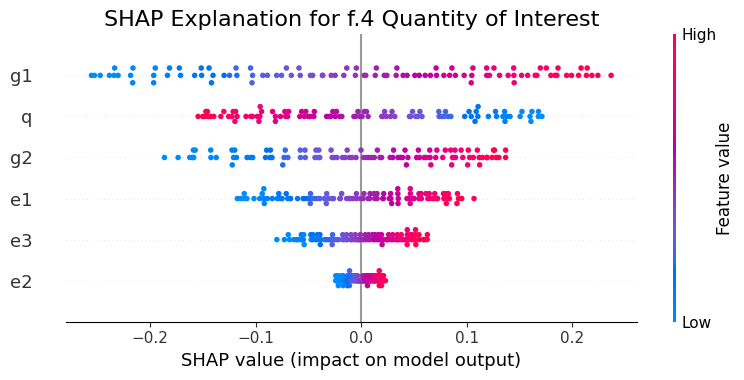

In [20]:
# Plot SHAP Beeswarm Plot
# The 'plot_shap_beeswarm' method generates a SHAP beeswarm plot, which visualizes the distribution of SHAP values
# for a range of test samples, showing the impact of each feature on the model’s predictions.
# - q: The test data (model.X_test.iloc[:100]) is selected for which SHAP values are calculated and visualized.
# - param_name: The name of the quantity of interest (QoI) for which SHAP values are computed ('f.4' in this case).
# The SHAP beeswarm plot shows how different input features influence the predictions across multiple samples,
# helping to understand the global feature importance and the relationships between features and the target.
fig = await model.plot_shap_beeswarm(X_test, q=X_test.iloc[:100], param_name='f.4')

In [21]:
# Make a prediction using the surrogate model
# - q_sample_df: A DataFrame containing the input parameter values for which the model will generate a prediction.
model.predict(q_sample_df)

array([[ 2.81226645,  2.87816751,  2.955402  ,  3.80484901,  0.43711232,
         0.29100068,  0.34135724,  0.37310518,  0.24920781,  0.29674105,
         0.19839353,  0.21698349,  0.14509418,  0.13520874,  0.08995678,
         0.05764575,  0.03804062, -0.24890221,  0.06929687, -0.11736139,
        -0.21170799,  0.0602394 , -0.16731891,  0.04793349, -0.12009466,
         0.03676505, -0.07225739,  0.0242405 , -0.02706651,  0.01116259,
         0.16636797,  0.17602263,  0.1735658 ,  0.14414382,  0.14987356,
         0.11620243,  0.11860772,  0.08623765,  0.08567523,  0.05466003,
         0.0522007 ,  0.02436639,  0.02139055,  0.36278906,  0.3568296 ,
         0.36063495,  0.31462165,  0.31220404,  0.25340066,  0.25172673,
         0.18666124,  0.18959405,  0.11573366,  0.12203901,  0.04640015,
         0.05451802,  0.24861801,  0.36805008,  0.32781299,  0.21344075,
         0.31242606,  0.17018085,  0.24604221,  0.12527097,  0.17831911,
         0.07899243,  0.10927322,  0.03482369,  0.0

# Update

## Synthetic measurement

In [22]:
qoi_m_df = pd.read_csv(data_path + 'z_m_df.csv')

## Set parameters

In [23]:
# For Update
sigma = pd.read_csv(data_path + 'sigma.csv')

# Generate the simulation parameter set (random noise) based on the updated measurement error (sigma)
E = generate_stndrn_variable_set(sigma.values.flatten())

nwalkers = 64  # Number of walkers (parallel chains) in the MCMC process
nburn = 1000  # Number of burn-in steps: these are discarded, as they help the MCMC chain reach equilibrium
niter = 100  # Total number of iterations for the MCMC process

In [24]:
# Initialize the Digital Twin model with the surrogate model and simulation parameter set (E)
DT = dt.DigitalTwin(model, E)  # Create a DigitalTwin instance that integrates the surrogate model and the random noise (E)

In [25]:
# Update the Digital Twin model with the synthetic measurement data and run MCMC sampling
DT.update(qoi_m_df, nwalkers=nwalkers, nburn=nburn, niter=niter)
# The 'update' method updates the Digital Twin using the synthetic measurement data (qoi_m_df)
# and performs MCMC sampling with the specified parameters (number of walkers, burn-in steps, and iterations)

MCMC creating
Burning period


100%|██████████| 1000/1000 [02:42<00:00,  6.16it/s]


MCMC running


100%|██████████| 100/100 [00:15<00:00,  6.51it/s]

--- 177.92773342132568 seconds ---


In [26]:
# Get the posterior mean and variance from the Digital Twin model
mean_of_post, variance_of_post = DT.get_mean_and_var_of_posterior()
# This returns the mean and variance of the posterior distribution after updating the model with data.

# Get the Maximum A Posteriori (MAP) estimate of the parameters
map = DT.get_MAP()
# This retrieves the most likely parameter values based on the updated model.

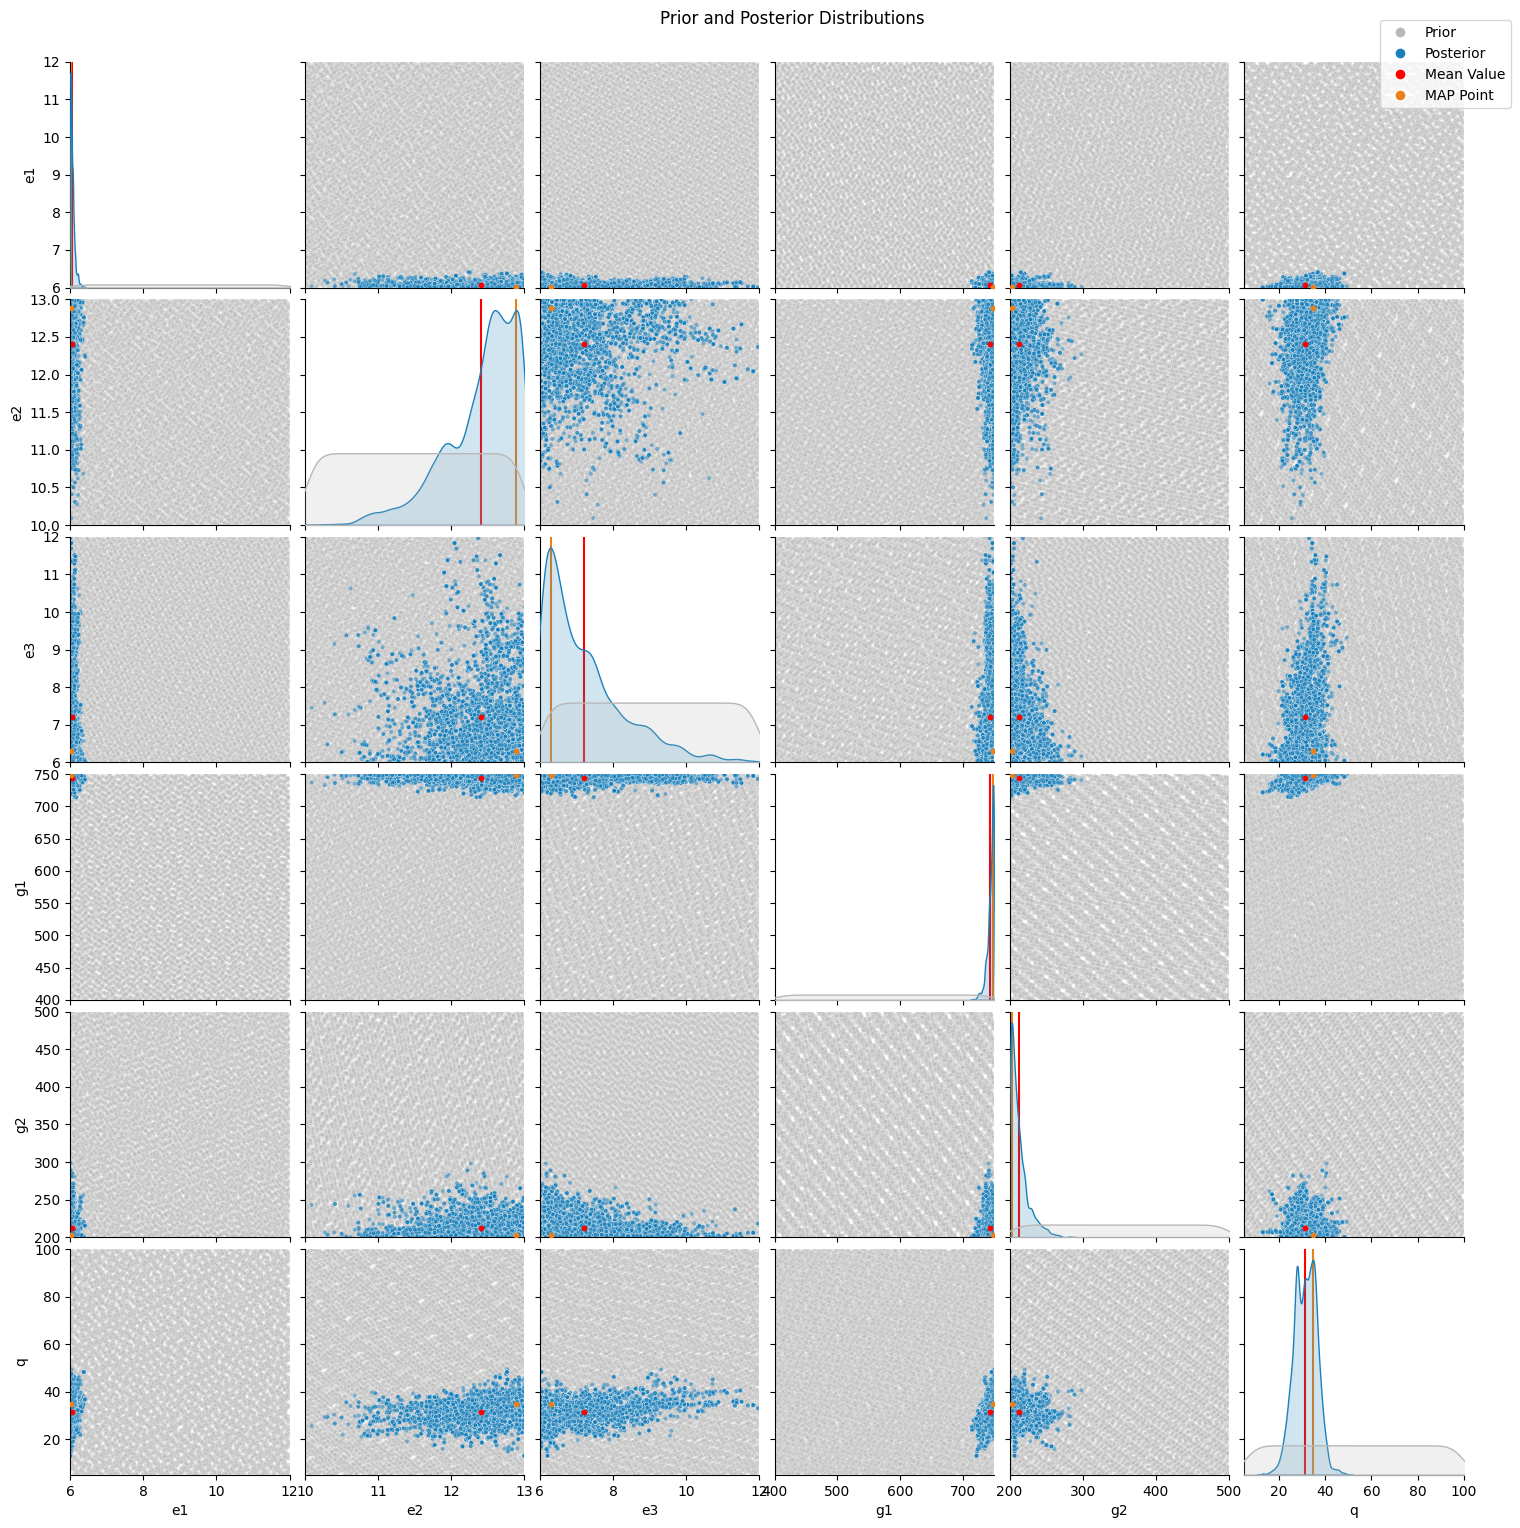

In [27]:
# Plot the MCMC sampling results along with the mean and MAP values
fig = dt.plot_MCMC(model, X_train, DT, nwalkers=nwalkers, map_point=map)

In [28]:
model.save_model('Yoker_model', '')  # Save the trained surrogate model to a file

Model saved to Yoker_model.sm
